KML file:
Z:\1\ARUNACHAL_REPORT\Upper Subansiri_extracted\doc.kml

Number of geometries: 1

SPATIAL EXTENT
West  / Minimum Longitude : 93.756419
South / Minimum Latitude  : 28.188040
East  / Maximum Longitude : 93.977711
North / Maximum Latitude  : 28.423734

EXTENT SIZE
Longitude span : 0.221292 degrees
Latitude span  : 0.235695 degrees

CENTROID
Longitude : 93.867240
Latitude  : 28.305012

BOUNDING BOX
North-West : 28.423734, 93.756419
North-East : 28.423734, 93.977711
South-West : 28.188040, 93.756419
South-East : 28.188040, 93.977711


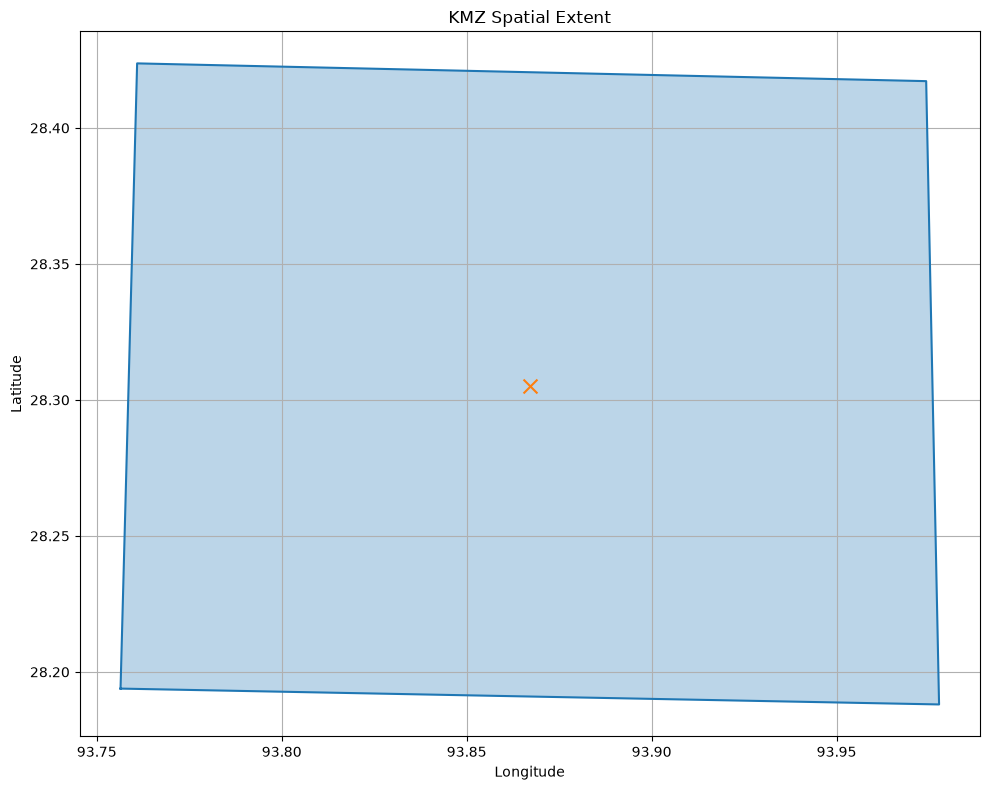

In [8]:
import os
import zipfile
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import unary_union
import matplotlib.pyplot as plt


# ============================================================
# 1. INPUT KMZ FILE
# ============================================================

input_file = r"Z:\1\ARUNACHAL_REPORT\Upper Subansiri.kmz"


# ============================================================
# 2. EXTRACT KMZ
# ============================================================

if input_file.lower().endswith(".kmz"):

    extract_folder = os.path.splitext(input_file)[0] + "_extracted"

    os.makedirs(extract_folder, exist_ok=True)

    with zipfile.ZipFile(input_file, "r") as kmz:
        kmz.extractall(extract_folder)

    # Find KML file
    kml_file = None

    for root, dirs, files in os.walk(extract_folder):
        for file in files:
            if file.lower().endswith(".kml"):
                kml_file = os.path.join(root, file)
                break

        if kml_file:
            break

    if kml_file is None:
        raise FileNotFoundError("No KML file found inside KMZ.")

else:

    kml_file = input_file


print("KML file:")
print(kml_file)


# ============================================================
# 3. READ KML XML
# ============================================================

tree = ET.parse(kml_file)
root = tree.getroot()

# KML namespace
namespace = {
    "kml": "http://www.opengis.net/kml/2.2"
}


# ============================================================
# 4. EXTRACT COORDINATES
# ============================================================

geometries = []


for coordinates in root.findall(".//kml:coordinates", namespace):

    text = coordinates.text

    if text is None:
        continue

    points = []

    for coord in text.strip().split():

        values = coord.split(",")

        lon = float(values[0])
        lat = float(values[1])

        points.append((lon, lat))


    if len(points) >= 3:

        # Polygon
        if points[0] != points[-1]:
            points.append(points[0])

        geom = Polygon(points)

        if geom.is_valid:
            geometries.append(geom)

        else:
            geometries.append(geom.buffer(0))

    elif len(points) == 2:

        # Line
        geometries.append(LineString(points))

    elif len(points) == 1:

        # Point
        geometries.append(Point(points[0]))


# ============================================================
# 5. CHECK GEOMETRIES
# ============================================================

if len(geometries) == 0:
    raise ValueError("No valid geometries found in the KML.")

print("\nNumber of geometries:", len(geometries))


# ============================================================
# 6. MERGE ALL GEOMETRIES
# ============================================================

combined = unary_union(geometries)


# ============================================================
# 7. CALCULATE EXTENT
# ============================================================

minx, miny, maxx, maxy = combined.bounds


print("\n" + "=" * 60)
print("SPATIAL EXTENT")
print("=" * 60)

print(f"West  / Minimum Longitude : {minx:.6f}")
print(f"South / Minimum Latitude  : {miny:.6f}")
print(f"East  / Maximum Longitude : {maxx:.6f}")
print(f"North / Maximum Latitude  : {maxy:.6f}")


# ============================================================
# 8. EXTENT SIZE
# ============================================================

longitude_span = maxx - minx
latitude_span = maxy - miny


print("\n" + "=" * 60)
print("EXTENT SIZE")
print("=" * 60)

print(f"Longitude span : {longitude_span:.6f} degrees")
print(f"Latitude span  : {latitude_span:.6f} degrees")


# ============================================================
# 9. CENTROID
# ============================================================

centroid = combined.centroid


print("\n" + "=" * 60)
print("CENTROID")
print("=" * 60)

print(f"Longitude : {centroid.x:.6f}")
print(f"Latitude  : {centroid.y:.6f}")


# ============================================================
# 10. BOUNDING BOX CORNERS
# ============================================================

print("\n" + "=" * 60)
print("BOUNDING BOX")
print("=" * 60)

print(
    f"North-West : {maxy:.6f}, {minx:.6f}"
)

print(
    f"North-East : {maxy:.6f}, {maxx:.6f}"
)

print(
    f"South-West : {miny:.6f}, {minx:.6f}"
)

print(
    f"South-East : {miny:.6f}, {maxx:.6f}"
)


# ============================================================
# 11. PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))


if combined.geom_type == "Polygon":

    x, y = combined.exterior.xy

    ax.plot(x, y)

    ax.fill(x, y, alpha=0.3)


elif combined.geom_type == "MultiPolygon":

    for polygon in combined.geoms:

        x, y = polygon.exterior.xy

        ax.plot(x, y)

        ax.fill(x, y, alpha=0.3)


elif combined.geom_type == "LineString":

    x, y = combined.xy

    ax.plot(x, y)


elif combined.geom_type == "MultiLineString":

    for line in combined.geoms:

        x, y = line.xy

        ax.plot(x, y)


ax.scatter(
    centroid.x,
    centroid.y,
    marker="x",
    s=100
)


ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("KMZ Spatial Extent")

ax.grid(True)

plt.tight_layout()

plt.show()

In [9]:
# ============================================================
# GIOVANNI BOUNDING BOX
# Format:
# West, South, East, North
# ============================================================

minx, miny, maxx, maxy = combined.bounds

giovanni_extent = f"{minx:.6f},{miny:.6f},{maxx:.6f},{maxy:.6f}"

print("\n" + "=" * 60)
print("GIOVANNI REGION")
print("=" * 60)

print(giovanni_extent)


GIOVANNI REGION
93.756419,28.188040,93.977711,28.423734


In [ ]:
import requests

# ============================================================
# EARTHDATA LOGIN
# ============================================================

USERNAME = "jintu_2000"
PASSWORD = "YJintu@1234567890Bhuyan@123"

session = requests.Session()

session.auth = (USERNAME, PASSWORD)

# ============================================================
# EARTHDATA LOGIN TEST
# ============================================================

url = "https://urs.earthdata.nasa.gov"

response = session.get(
    url,
    allow_redirects=True
)

print("Status code:", response.status_code)
print("Final URL:", response.url)

if response.ok:
    print("Earthdata Login connection successful.")
else:
    print("Earthdata Login failed.")